In [1]:
# ===============================================
# 1) Install Required Libraries
# ===============================================

!pip install -q torch torchvision scikit-learn matplotlib seaborn kaggle tqdm

In [2]:
# ===============================================
# 2) Import Libraries
# ===============================================

import os
import re
import random
import zipfile
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset

import torchvision.transforms.functional as TF
from torchvision import datasets, transforms

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.calibration import calibration_curve

from google.colab import files

In [3]:
# ===============================================
# 3) Configuration And Reproducibility
# ===============================================

KAGGLE_JSON_PATH = "/root/.kaggle/kaggle.json"
DATA_DIR = "/content/data"
DATASET_NAME = "paultimothymooney/chest-xray-pneumonia"
ZIP_PATH = os.path.join(DATA_DIR, "chest-xray-pneumonia.zip")

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 5e-5
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 7
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

CLASS_NAMES = {0: "Normal", 1: "Pneumonia"}

BEST_MODEL_PATH = "/content/deepcnn_pneumonia_best.pt"
LAST_MODEL_PATH = "/content/deepcnn_pneumonia_last_epoch.pt"
THRESHOLD_PATH = "/content/best_threshold.txt"
SPLIT_PATH = "/content/split_indices.npz"

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(_worker_id):
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator().manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# ===============================================
# 4) Dataset Download And Extraction
# ===============================================

print("\nChecking Kaggle credentials...")

if not os.path.exists(KAGGLE_JSON_PATH):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

    if "kaggle.json" not in uploaded:
        raise FileNotFoundError("Please upload kaggle.json")

    os.makedirs("/root/.kaggle", exist_ok=True)
    os.replace("kaggle.json", KAGGLE_JSON_PATH)
    os.chmod(KAGGLE_JSON_PATH, 0o600)

os.makedirs(DATA_DIR, exist_ok=True)
print("Downloading dataset...")

if not os.path.exists(ZIP_PATH):
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", DATASET_NAME, "-p", DATA_DIR],
        check=True
    )
    print("Download completed.")
else:
    print("Dataset archive already exists.")

print("Extracting dataset...")

if not any(Path(DATA_DIR).rglob("train")):
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

def find_split_root(base_dir):
    base_dir = Path(base_dir)
    image_exts = {".jpg", ".jpeg", ".png", ".bmp"}

    for train_path in sorted(base_dir.rglob("train")):
        if "__MACOSX" in train_path.parts:
            continue

        root = train_path.parent

        expected = [
            root / "train" / "NORMAL",
            root / "train" / "PNEUMONIA",
            root / "val" / "NORMAL",
            root / "val" / "PNEUMONIA",
            root / "test" / "NORMAL",
            root / "test" / "PNEUMONIA",
        ]

        if not all(path.exists() for path in expected):
            continue

        imgs = [
            path for path in (root / "train" / "NORMAL").iterdir()
            if path.suffix.lower() in image_exts
        ]

        if imgs:
            return str(root)

    raise FileNotFoundError("Could not find chest_xray dataset structure.")

XRAY_ROOT = find_split_root(DATA_DIR)
print("Dataset root:", XRAY_ROOT)


Checking Kaggle credentials...
Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Download completed.
Extracting dataset...
Dataset extracted.
Dataset root: /content/data/chest_xray/chest_xray


In [5]:
# ===============================================
# 5) Data Preparation And Leakage Prevention
# ===============================================

raw_split_dirs = [f"{XRAY_ROOT}/train", f"{XRAY_ROOT}/val", f"{XRAY_ROOT}/test"]
base_datasets = [datasets.ImageFolder(split_dir) for split_dir in raw_split_dirs]

for split_index, dataset_item in enumerate(base_datasets):
    assert dataset_item.class_to_idx == base_datasets[0].class_to_idx, \
        f"Class mapping mismatch in split {split_index}: {dataset_item.class_to_idx}"

assert base_datasets[0].class_to_idx.get("NORMAL") == 0, "Unexpected index for NORMAL"
assert base_datasets[0].class_to_idx.get("PNEUMONIA") == 1, "Unexpected index for PNEUMONIA"

full_dataset = ConcatDataset(base_datasets)

all_paths = []
all_labels_list = []

for dataset_item in base_datasets:
    for path, label in dataset_item.samples:
        all_paths.append(path)
        all_labels_list.append(label)

all_labels = np.array(all_labels_list)
all_indices = np.arange(len(all_labels))

print(f"\nTotal images loaded : {len(all_indices)}")
print(f"Class distribution  : Normal={np.sum(all_labels == 0)}, Pneumonia={np.sum(all_labels == 1)}")

def extract_patient_id(path):
    file_name = os.path.basename(path).lower()
    stem = os.path.splitext(file_name)[0]

    match = re.search(r"person(\d+)", stem)
    if match:
        return f"patient_pneumonia_{match.group(1)}"

    match = re.match(r"(normal2-)?im-(\d+)", stem)
    if match:
        prefix = "n2" if match.group(1) else "n1"
        return f"patient_normal_{prefix}_{match.group(2)}"

    return f"unique_{stem}"

patient_ids = np.array([extract_patient_id(path) for path in all_paths])
_, group_ids = np.unique(patient_ids, return_inverse=True)

print(f"Unique patient IDs  : {len(np.unique(patient_ids))}")
print(f"Unique group IDs    : {len(np.unique(group_ids))}")

sgkf1 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
folds = list(sgkf1.split(all_indices, all_labels, groups=group_ids))

temp_idx = np.concatenate([folds[i][1] for i in range(3)])
train_idx = np.setdiff1d(all_indices, temp_idx)

temp_labels = all_labels[temp_idx]
temp_groups = group_ids[temp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
val_rel, test_rel = next(sgkf2.split(temp_idx, temp_labels, groups=temp_groups))

val_idx = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

train_pts = set(group_ids[train_idx])
val_pts = set(group_ids[val_idx])
test_pts = set(group_ids[test_idx])

assert train_pts.isdisjoint(val_pts), "Leakage: train and val share patients!"
assert train_pts.isdisjoint(test_pts), "Leakage: train and test share patients!"
assert val_pts.isdisjoint(test_pts), "Leakage: val and test share patients!"

print("\n✓ Verification Passed: No patient overlap across train / val / test.")
print(f"Train size : {len(train_idx)}")
print(f"Val size   : {len(val_idx)}")
print(f"Test size  : {len(test_idx)}")

def print_split_distribution(name, labels):
    counts = np.bincount(labels, minlength=2)
    total = counts.sum()

    print(f"\n{name}")
    print("-" * 32)
    print(f"Normal    : {counts[0]} ({counts[0] / total * 100:.2f}%)")
    print(f"Pneumonia : {counts[1]} ({counts[1] / total * 100:.2f}%)")
    print(f"Total     : {total}")

print_split_distribution("Train", all_labels[train_idx])
print_split_distribution("Validation", all_labels[val_idx])
print_split_distribution("Test", all_labels[test_idx])

np.savez(
    SPLIT_PATH,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    all_labels=all_labels,
    group_ids=group_ids,
    patient_ids=patient_ids,
    all_paths=np.array(all_paths)
)

print(f"\nSplit indices saved to: {SPLIT_PATH}")


Total images loaded : 5856
Class distribution  : Normal=1583, Pneumonia=4273
Unique patient IDs  : 3118
Unique group IDs    : 3118

✓ Verification Passed: No patient overlap across train / val / test.
Train size : 4067
Val size   : 907
Test size  : 882

Train
--------------------------------
Normal    : 1104 (27.15%)
Pneumonia : 2963 (72.85%)
Total     : 4067

Validation
--------------------------------
Normal    : 242 (26.68%)
Pneumonia : 665 (73.32%)
Total     : 907

Test
--------------------------------
Normal    : 237 (26.87%)
Pneumonia : 645 (73.13%)
Total     : 882

Split indices saved to: /content/split_indices.npz


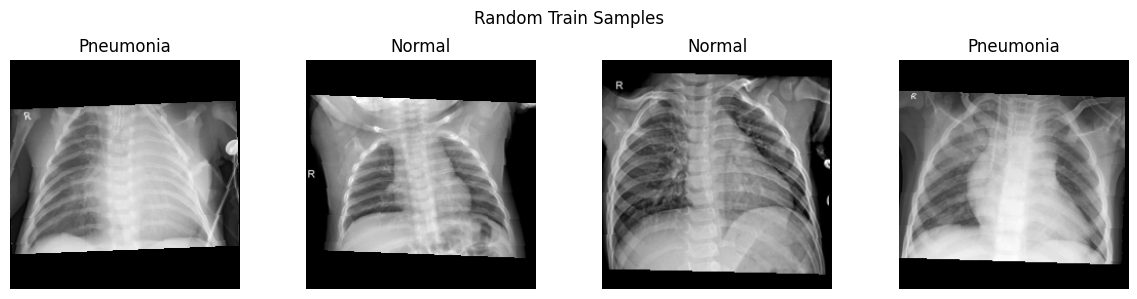

In [6]:
# ===============================================
# 6) Data Augmentation And Loaders
# ===============================================

class SquarePad:

    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        width, height = img.size

        scale = self.size / max(width, height)
        new_width = int(round(width * scale))
        new_height = int(round(height * scale))

        img = TF.resize(img, [new_height, new_width])

        pad_width = self.size - new_width
        pad_height = self.size - new_height

        left = pad_width // 2
        top = pad_height // 2

        return TF.pad(img, [left, top, pad_width - left, pad_height - top], fill=0)

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    SquarePad(IMG_SIZE),
    transforms.RandomRotation(3, fill=0),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02), fill=0),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    SquarePad(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

class TransformedSubset(torch.utils.data.Dataset):

    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[int(self.indices[idx])]
        return self.transform(image), int(label)

train_ds = TransformedSubset(full_dataset, train_idx, train_transform)
val_ds = TransformedSubset(full_dataset, val_idx, eval_transform)
test_ds = TransformedSubset(full_dataset, test_idx, eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=loader_generator,
    drop_last=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker
)

def denormalize(img):
    return (img * 0.5 + 0.5).clamp(0, 1)

def show_random_samples(dataset, n=4, title="Samples"):
    sample_indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, sample_indices):
        img, label = dataset[idx]

        ax.imshow(denormalize(img)[0], cmap="gray")
        ax.set_title(CLASS_NAMES[label])
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_random_samples(train_ds, title="Random Train Samples")

set_all_seeds(SEED)

In [7]:
# ===============================================
# 7) Model Architecture
# ===============================================

class DeepCNN(nn.Module):

    def __init__(self):
        super().__init__()

        def block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(1, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.features(x)
        output = self.classifier(features)
        return output

model = DeepCNN().to(device)

In [8]:
# ===============================================
# 8) Loss And Optimizer Configuration
# ===============================================

train_labels = all_labels[train_idx]
class_counts = np.bincount(train_labels, minlength=2)

class_weights = torch.tensor(
    len(train_labels) / (len(class_counts) * class_counts),
    dtype=torch.float
).to(device)

print("\nClass counts:", class_counts)
print("Class weights applied to Loss Function:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)


Class counts: [1104 2963]
Class weights applied to Loss Function: [1.8419384  0.68629766]


In [9]:
# ===============================================
# 9) Training Loop
# ===============================================

def train_epoch(loader):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def eval_epoch(loader, desc="Eval"):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_true_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            prob = torch.softmax(outputs, dim=1)[:, 1]

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

            all_true_labels.extend(labels.cpu().numpy())
            all_probs.extend(prob.cpu().numpy())

    fpr, tpr, _ = roc_curve(all_true_labels, all_probs)

    return total_loss / total, correct / total, auc(fpr, tpr)

train_losses, train_accs = [], []
val_losses, val_accs, val_aucs = [], [], []

best_val_auc = -np.inf
best_epoch = 0
epochs_no_improve = 0

print("\nStarting Training Phase...")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(train_loader)
    val_loss, val_acc, val_auc = eval_epoch(val_loader, desc="Val")

    scheduler.step(val_auc)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        epochs_no_improve = 0

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        tag = " ← best"
    else:
        epochs_no_improve += 1
        tag = ""

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS}: "
        f"Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
        f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}, AUC={val_auc:.4f}{tag}"
    )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch + 1} epochs!")
        break

torch.save(model.state_dict(), LAST_MODEL_PATH)

print(f"\nTraining finished.")
print(f"Best epoch    : {best_epoch}")
print(f"Best Val AUC  : {best_val_auc:.4f}")


Starting Training Phase...


Epoch 01/20: Train Loss=0.3945, Acc=0.8436 | Val Loss=0.2526, Acc=0.9261, AUC=0.9720 ← best


Epoch 02/20: Train Loss=0.2588, Acc=0.9066 | Val Loss=0.2793, Acc=0.8897, AUC=0.9781 ← best


Epoch 03/20: Train Loss=0.2227, Acc=0.9196 | Val Loss=0.5493, Acc=0.7596, AUC=0.9864 ← best


Epoch 04/20: Train Loss=0.2087, Acc=0.9248 | Val Loss=0.2250, Acc=0.9052, AUC=0.9888 ← best


...

Epoch 16/20: Train Loss=0.1017, Acc=0.9656 | Val Loss=0.0878, Acc=0.9746, AUC=0.9952 ← best


Epoch 17/20: Train Loss=0.0958, Acc=0.9678 | Val Loss=0.1121, Acc=0.9570, AUC=0.9949


Epoch 18/20: Train Loss=0.0949, Acc=0.9666 | Val Loss=0.1969, Acc=0.9239, AUC=0.9960 ← best


Epoch 19/20: Train Loss=0.0950, Acc=0.9678 | Val Loss=0.2621, Acc=0.9074, AUC=0.9959


Epoch 20/20: Train Loss=0.0959, Acc=0.9651 | Val Loss=0.0899, Acc=0.9713, AUC=0.9962 ← best

Training finished.
Best epoch    : 20
Best Val AUC  : 0.9962



Loaded best model from: /content/deepcnn_pneumonia_best.pt
Best optimized threshold (Youden's J): 0.8731

Classification Report (Test Set)
              precision    recall  f1-score   support

      Normal       0.85      0.97      0.91       237
   Pneumonia       0.99      0.94      0.96       645

    accuracy                           0.95       882
   macro avg       0.92      0.95      0.93       882
weighted avg       0.95      0.95      0.95       882

ROC AUC : 0.9909
PR  AUC : 0.9966


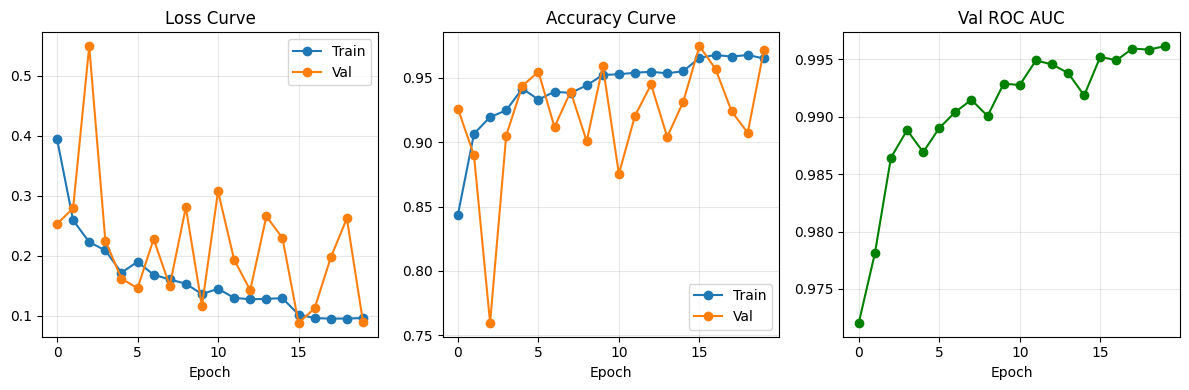

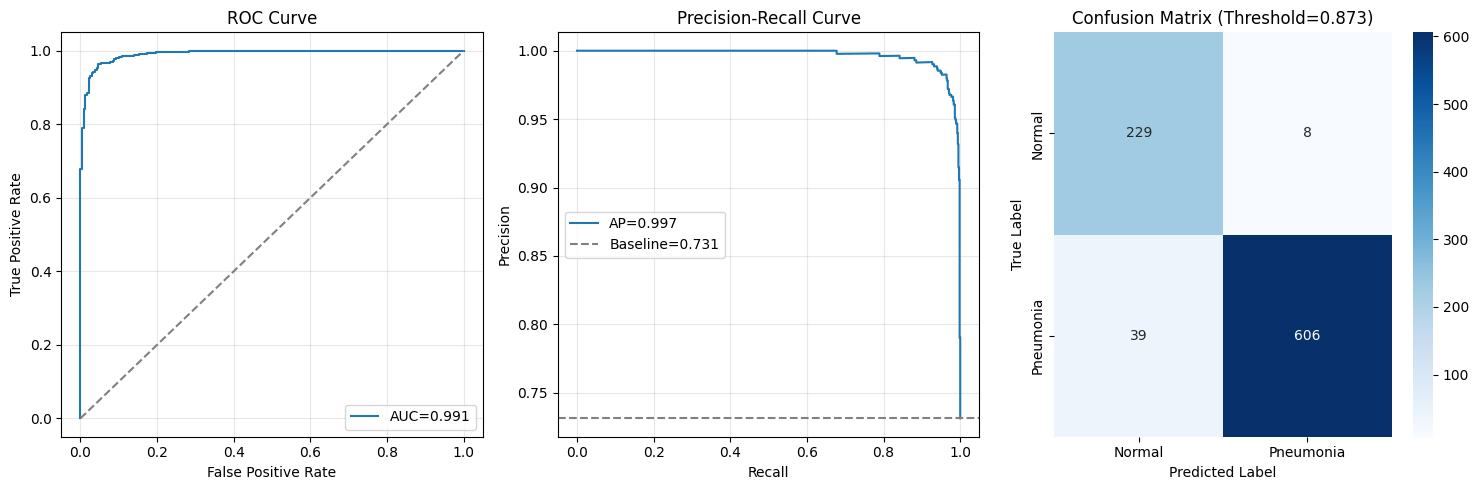

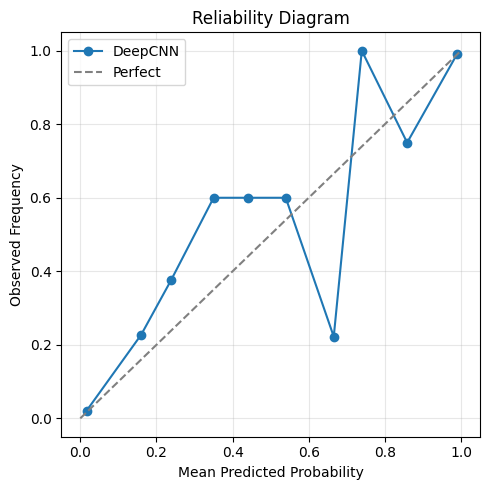

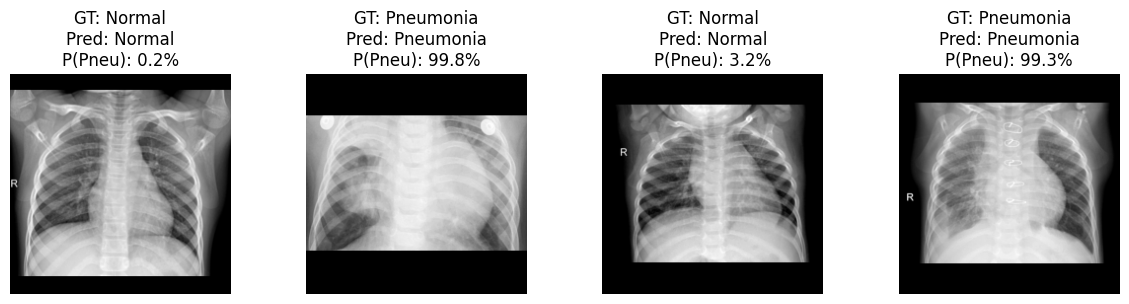

In [10]:
# ===============================================
# 10) Evaluation And Visualization
# ===============================================

try:
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
except TypeError:
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.eval()
print(f"\nLoaded best model from: {BEST_MODEL_PATH}")

def collect_probs(loader):
    y_true, y_prob = [], []

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            probs = torch.softmax(model(images.to(device)), dim=1)[:, 1]

            y_true.extend(labels.numpy())
            y_prob.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_prob)

val_true, val_prob = collect_probs(val_loader)
val_fpr, val_tpr, val_thr = roc_curve(val_true, val_prob)

youden_j = val_tpr - val_fpr
finite_mask = np.isfinite(val_thr)

best_thr = float(val_thr[finite_mask][np.argmax(youden_j[finite_mask])]) if finite_mask.any() else 0.5

with open(THRESHOLD_PATH, "w") as file:
    file.write(str(best_thr))

print(f"Best optimized threshold (Youden's J): {best_thr:.4f}")

y_true, y_prob = collect_probs(test_loader)
y_pred = (y_prob >= best_thr).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_true, y_prob)

print("\nClassification Report (Test Set)")
print("=" * 45)
print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values()), zero_division=0))
print(f"ROC AUC : {roc_auc:.4f}")
print(f"PR  AUC : {pr_auc:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, "-o", label="Train")
plt.plot(val_losses, "-o", label="Val")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_accs, "-o", label="Train")
plt.plot(val_accs, "-o", label="Val")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(val_aucs, "-o", color="green")
plt.title("Val ROC AUC")
plt.xlabel("Epoch")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()

_, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

precision, recall, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(recall, precision, label=f"AP={pr_auc:.3f}")
axes[1].axhline(y_true.mean(), ls="--", color="gray", label=f"Baseline={y_true.mean():.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(CLASS_NAMES.values()),
    yticklabels=list(CLASS_NAMES.values()),
    ax=axes[2]
)

axes[2].set(
    xlabel="Predicted Label",
    ylabel="True Label",
    title=f"Confusion Matrix (Threshold={best_thr:.3f})"
)

plt.tight_layout()
plt.savefig("/content/evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(mean_pred, frac_pos, "o-", label="DeepCNN")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/calibration.png", dpi=150)
plt.show()

def show_random_predictions(dataset, model, threshold, n=4):
    sample_indices = random.sample(range(len(dataset)), n)

    _, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    if n == 1:
        axes = [axes]

    model.eval()

    for ax, idx in zip(axes, sample_indices):
        img, label = dataset[idx]

        with torch.no_grad():
            prob = torch.softmax(
                model(img.unsqueeze(0).to(device)),
                dim=1
            )[0, 1].item()

        pred = 1 if prob >= threshold else 0

        ax.imshow(denormalize(img)[0], cmap="gray")
        ax.set_title(
            f"GT: {CLASS_NAMES[label]}\n"
            f"Pred: {CLASS_NAMES[pred]}\n"
            f"P(Pneu): {prob * 100:.1f}%"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_predictions(test_ds, model, best_thr)

In [11]:
# ===============================================
# 11) Final Summary
# ===============================================

print("\nFinal Summary")
print("=" * 45)
print(f"Best model path       : {BEST_MODEL_PATH}")
print(f"Last epoch model path : {LAST_MODEL_PATH}")
print(f"Threshold path        : {THRESHOLD_PATH}")
print(f"Split indices path    : {SPLIT_PATH}")
print("-" * 45)
print(f"Best epoch            : {best_epoch}")
print(f"Best Val AUC          : {best_val_auc:.4f}")
print(f"Optimal Threshold     : {best_thr:.4f}")
print(f"Test ROC AUC          : {roc_auc:.4f}")
print(f"Test PR  AUC          : {pr_auc:.4f}")
print("\n✓ Pipeline finished. Models & plots saved to /content/")


Final Summary
Best model path       : /content/deepcnn_pneumonia_best.pt
Last epoch model path : /content/deepcnn_pneumonia_last_epoch.pt
Threshold path        : /content/best_threshold.txt
Split indices path    : /content/split_indices.npz
---------------------------------------------
Best epoch            : 20
Best Val AUC          : 0.9962
Optimal Threshold     : 0.8731
Test ROC AUC          : 0.9909
Test PR  AUC          : 0.9966

✓ Pipeline finished. Models & plots saved to /content/
